,metric,value
0,JS divergence,0.08318
1,PSI,0.36335


Probability: Significant drift
Entropy: Significant drift
Overall decision: Significant drift


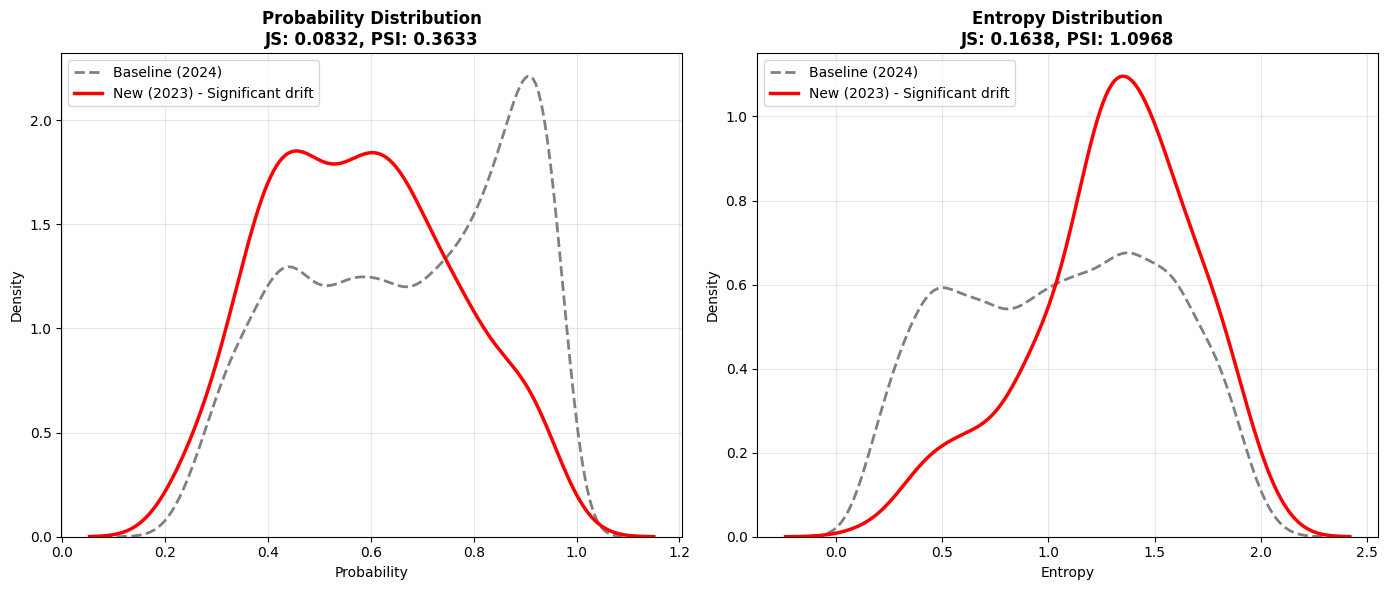

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import drift metrics functions from our module
from drift_metrics import (
    js_divergence_from_samples,
    psi_from_samples,
    calculate_drift_metrics
)

# Setup paths
ROOT = Path("/workspaces/platform_data_drift")
processed_dir = ROOT / "data" / "processed"

# Load data
baseline = pd.read_csv(processed_dir / "madrid_merge_2024_no_entropy.csv")

new_data = pd.read_csv(processed_dir / "madrid_merge_2003_no_entropy.csv")

baseline_probs = baseline["probability"]
new_probs = new_data["probability"]

def add_entropy(
    df: pd.DataFrame,
    prob_prefix: str = "prob-",
    out_col: str = "entropy",
    base: float | None = None,   # None = natural log; use 2 for bits
    eps: float = 1e-12,
    normalize: bool = False      # if True, divide by log(K) so range ~[0,1]
) -> pd.DataFrame:
    """
    Adds Shannon entropy of the per-row probability vector to df.

    Expects class-probability columns like 'prob-Quartz', 'prob-Schist_Felsic', etc.
    """
    prob_cols = [c for c in df.columns if c.startswith(prob_prefix)]
    if not prob_cols:
        raise ValueError(f"No columns found starting with '{prob_prefix}'")

    p = df[prob_cols].to_numpy(dtype=float)

    # optional: renormalize rows in case probabilities don't sum to 1
    row_sums = p.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = np.nan
    p = p / row_sums

    log_fn = np.log if base is None else (lambda x: np.log(x) / np.log(base))
    H = -np.nansum(p * log_fn(p + eps), axis=1)

    if normalize:
        K = len(prob_cols)
        H = H / log_fn(K)

    out = df.copy()
    out[out_col] = H
    return out

baseline = add_entropy(baseline)
new_data = add_entropy(new_data)

baseline_entropy = baseline["entropy"]
new_entropy = new_data["entropy"]

# Calculate drift metrics using the module functions
js = js_divergence_from_samples(new_probs, baseline_probs)
psi = psi_from_samples(baseline_probs, new_probs)

metrics = pd.DataFrame({
    "metric": ["JS divergence", "PSI"],
    "value": [js, psi]
})

from drift_metrics import classify_drift, get_drift_color, DriftThresholds

# Define thresholds (can also use defaults by omitting this)
thresholds = DriftThresholds(
    js_high=0.04,
    js_moderate=0.02,
    psi_high=0.25,
    psi_moderate=0.10
)

# Calculate drift metrics for both probability and entropy
js_prob = js_divergence_from_samples(new_probs, baseline_probs)
psi_prob = psi_from_samples(baseline_probs, new_probs)

js_entropy = js_divergence_from_samples(new_entropy, baseline_entropy)
psi_entropy = psi_from_samples(baseline_entropy, new_entropy)

# Get drift classification and colors
prob_color, prob_label = get_drift_color(js_prob, psi_prob, thresholds)
entropy_color, entropy_label = get_drift_color(js_entropy, psi_entropy, thresholds)

# Print decision
decision = classify_drift(js_prob, psi_prob, thresholds)

# Print summary
display(metrics)
print(f"Probability: {prob_label}")
print(f"Entropy: {entropy_label}")
print(f"Overall decision: {decision}")

# Create KDE plots with drift-based colors
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(baseline_probs, label='Baseline (2024)', color='gray', linestyle='--', linewidth=2)
sns.kdeplot(new_probs, label=f'New (2023) - {prob_label}', color=prob_color, linewidth=2.5)
plt.title(f'Probability Distribution\nJS: {js_prob:.4f}, PSI: {psi_prob:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.kdeplot(baseline_entropy, label='Baseline (2024)', color='gray', linestyle='--', linewidth=2)
sns.kdeplot(new_entropy, label=f'New (2023) - {entropy_label}', color=entropy_color, linewidth=2.5)
plt.title(f'Entropy Distribution\nJS: {js_entropy:.4f}, PSI: {psi_entropy:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Entropy')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()